<a href="https://colab.research.google.com/github/SakshyamAryal077/Class-Balancing-Techniques-for-MIT-BIH-ARRYTHMIA-DETECTION./blob/main/proximityweight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# If needed, install imbalanced-learn
!pip install imbalanced-learn


In [ ]:
import numpy as np
import torch
from imblearn.over_sampling import ADASYN
from google.colab import files
from sklearn.preprocessing import LabelEncoder




In [ ]:
# Load your saved subset files
X_train_small = np.load("X_trainsmall.npy")
y_train_small = np.load("y_trainsmall.npy")

print("Original X_train_small shape:", X_train_small.shape)
print("Original y_train_small shape:", y_train_small.shape)

classes, counts = np.unique(y_train_small, return_counts=True)
print("\nClass distribution before adasyn:")
for cls, cnt in zip(classes, counts):
    print(f"Class {cls}: {cnt}")


Original X_train_small shape: (27010, 360, 1)
Original y_train_small shape: (27010,)

Class distribution before smoteenn:
Class 0: 193
Class 1: 21680
Class 2: 2734
Class 3: 667
Class 4: 1736


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from collections import Counter

def proximity_weighted_synthetic_oversampling(X, y, random_state=42, k_neighbors=5):
    np.random.seed(random_state)

    class_counts = Counter(y)
    max_count = max(class_counts.values())

    X_resampled = [X]
    y_resampled = [y]

    classes = sorted(class_counts.keys())

    for cls in classes:
        X_min = X[y == cls]
        y_min = y[y == cls]

        X_maj = X[y != cls]

        n_min = len(X_min)
        n_to_generate = max_count - n_min

        if n_to_generate <= 0:
            continue

        # nearest majority neighbor = approximate decision boundary distance
        nn_majority = NearestNeighbors(n_neighbors=1)
        nn_majority.fit(X_maj)
        dists_to_boundary, _ = nn_majority.kneighbors(X_min)

        # proximity weight from paper idea: PW_x = g(d(x,B))
        # practical assumption: g(d) = d
        pw = dists_to_boundary.flatten()

        # we want more samples near boundary, so use inverse PW for seed selection
        seed_probs = 1.0 / (pw + 1e-8)
        seed_probs = seed_probs / seed_probs.sum()

        # same-class neighbors for interpolation
        k_eff = min(k_neighbors, len(X_min))
        nn_minority = NearestNeighbors(n_neighbors=k_eff)
        nn_minority.fit(X_min)

        synthetic_samples = []

        for _ in range(n_to_generate):
            # choose minority seed, with higher chance for near-boundary samples
            i = np.random.choice(len(X_min), p=seed_probs)
            x_i = X_min[i]
            pw_i = pw[i]

            # choose same-class neighbor
            _, neighbor_ids = nn_minority.kneighbors([x_i])
            neighbor_ids = neighbor_ids.flatten()

            # remove self if possible
            neighbor_ids = neighbor_ids[neighbor_ids != i]
            if len(neighbor_ids) == 0:
                j = i
            else:
                j = np.random.choice(neighbor_ids)

            x_j = X_min[j]
            pw_j = pw[j]

            # paper formula:
            # alpha = PW_i / (PW_i + PW_j)
            alpha = pw_i / (pw_i + pw_j + 1e-8)

            # synthetic sample:
            # x_syn = x_i + alpha * (x_j - x_i)
            x_syn = x_i + alpha * (x_j - x_i)

            synthetic_samples.append(x_syn)

        synthetic_samples = np.array(synthetic_samples)
        synthetic_labels = np.full(len(synthetic_samples), cls)

        X_resampled.append(synthetic_samples)
        y_resampled.append(synthetic_labels)

    X_final = np.vstack(X_resampled)
    y_final = np.hstack(y_resampled)

    return X_final, y_final


In [ ]:
print("Original X_train_small shape:", X_train_small.shape)
print("Original y_train_small shape:", y_train_small.shape)

classes_before, counts_before = np.unique(y_train_small, return_counts=True)
print("\nClass distribution before ProWSyn:")
for cls, cnt in zip(classes_before, counts_before):
    print(f"Class {cls}: {cnt}")

# flatten for neighbor-based processing
X_train_flat = X_train_small.reshape(X_train_small.shape[0], -1)
print("\nFlattened X shape:", X_train_flat.shape)

X_train_prowsyn, y_train_prowsyn = proximity_weighted_synthetic_oversampling(
    X_train_flat,
    y_train_small,
    random_state=42,
    k_neighbors=5
)

print("\nAfter ProWSyn X shape:", X_train_prowsyn.shape)
print("After ProWSyn y shape:", y_train_prowsyn.shape)

# reshape back to original ECG format
X_train_prowsyn = X_train_prowsyn.reshape(-1, *X_train_small.shape[1:])
print("Reshaped X_train_prowsyn shape:", X_train_prowsyn.shape)

classes_after, counts_after = np.unique(y_train_prowsyn, return_counts=True)
print("\nClass distribution after ProWSyn:")
for cls, cnt in zip(classes_after, counts_after):
    print(f"Class {cls}: {cnt}")



Original X_train_small shape: (27010, 360, 1)
Original y_train_small shape: (27010,)

Class distribution before ProWSyn:
Class 0: 193
Class 1: 21680
Class 2: 2734
Class 3: 667
Class 4: 1736

Flattened X shape: (27010, 360)

After ProWSyn X shape: (108400, 360)
After ProWSyn y shape: (108400,)
Reshaped X_train_prowsyn shape: (108400, 360, 1)

Class distribution after ProWSyn:
Class 0: 21680
Class 1: 21680
Class 2: 21680
Class 3: 21680
Class 4: 21680


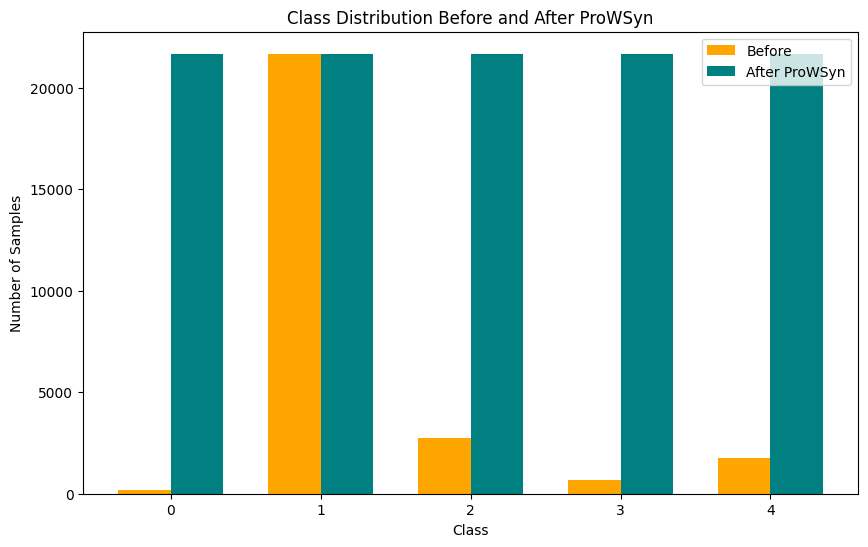

In [ ]:
plt.figure(figsize=(10, 6))

x = np.arange(len(classes_before))
width = 0.35

plt.bar(x - width/2, counts_before, width, label='Before', color='orange')
plt.bar(x + width/2, counts_after, width, label='After ProWSyn', color='teal')

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution Before and After ProWSyn")
plt.xticks(x, classes_before)
plt.legend()
plt.show()


In [ ]:
np.save("X_train_prowsyn.npy", X_train_prowsyn)
np.save("y_train_prowsyn.npy", y_train_prowsyn)

print("\nSaved files:")
print("X_train_prowsyn.npy")
print("y_train_prowsyn.npy")



Saved files:
X_train_prowsyn.npy
y_train_prowsyn.npy
